# HW5 — Walmart Store Sales Forecasting (Time Series)

**Course:** Machine Learning II — IE University Madrid  
**Professor:** Jaume Manero Font  
**Author:** Elad Moshe  
**Program:** MCSBT  
**Date:** June 2026

---

## Overview

This notebook covers both deliverables for the Kaggle competition **Walmart Recruiting — Store Sales Forecasting**: historical weekly sales data for 45 stores × 99 departments, with external covariates (temperature, fuel price, CPI, unemployment) and holiday flags. The challenge is to predict a 39-week forward horizon.

The evaluation metric is **Weighted Mean Absolute Error (WMAE)**, identical to MAE except that holiday weeks receive a 5× weight — so nailing Thanksgiving and Christmas forecasts matters disproportionately.

**Key insights from top public solutions:**
- #1 place used SVD denoising per department + STL decomposition + ETS ensemble in R (WMAE ≈ 2300).
- Top ML solutions (Random Forest / XGBoost) with proper holiday features achieved WMAE ≈ 1300–1800.
- The single most impactful trick: align holiday lags by holiday *type* (Thanksgiving is always the 4th Thursday of November) rather than a fixed 52-week offset, since a 52-week shift drifts ±1 week from year to year.

## Notebook Structure

1. [Google Drive Setup](#0.-Google-Drive-Setup)
2. [Exploratory Data Analysis](#1.-Exploratory-Data-Analysis)
3. [Data Preparation](#2.-Data-Preparation)
4. [Part 1 — Classical Baseline (Mandatory)](#3.-Part-1-—-Classical-Baseline)
5. [Part 2 — LightGBM Solution (Optional)](#4.-Part-2-—-LightGBM-Solution)
6. [Results Summary](#5.-Results-Summary)

---

> **AI Usage Disclaimer:** I used AI assistance (Claude, Anthropic) while building this notebook: drafting markdown explanations, structuring the EDA, debugging the feature engineering pipeline, and reviewing the checkpointing logic. I also reviewed public Kaggle write-ups for this competition for insights on holiday alignment and feature selection. Modelling decisions and result interpretation are my own.

## 0. Setup

Run cells top to bottom each session:
1. Mount Drive, install packages, import libraries
2. **Upload the dataset zip** when prompted — the cell extracts the CSVs automatically
3. Everything else runs from there

Model checkpoints and submissions are saved to `My Drive/AdvML_HW5/` and persist between sessions.

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
print('Drive mounted.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [ ]:
!pip install -q lightgbm optuna joblib pyarrow statsmodels


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import lightgbm as lgb
import joblib, optuna, json
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/AdvML_HW5'
DATA_DIR = '/content/walmart_data'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
print(f'SAVE_DIR = {SAVE_DIR}')
print(f'DATA_DIR = {DATA_DIR}')


SAVE_DIR = /content/drive/MyDrive/AdvML_HW5
DATA_DIR = /content/walmart_data


In [ ]:
from google.colab import files as _cf
import zipfile, io as _io

print('Select and upload the dataset zip file...')
uploaded = _cf.upload()
zip_path = list(uploaded.keys())[0]

os.makedirs(DATA_DIR, exist_ok=True)
with zipfile.ZipFile(zip_path) as zf:
    for member in zf.namelist():
        flat = os.path.basename(member)
        if not flat:
            continue
        if flat.endswith('.csv'):
            # plain CSV — extract directly
            with zf.open(member) as src, open(os.path.join(DATA_DIR, flat), 'wb') as dst:
                dst.write(src.read())
            print(f'  Extracted: {flat}')
        elif flat.endswith('.csv.zip'):
            # nested zip (e.g. train.csv.zip) — unzip the inner file
            csv_name = flat[:-4]  # strip .zip -> train.csv
            with zf.open(member) as raw:
                with zipfile.ZipFile(_io.BytesIO(raw.read())) as inner:
                    inner_csv = [m for m in inner.namelist() if m.endswith('.csv')][0]
                    with inner.open(inner_csv) as src, open(os.path.join(DATA_DIR, csv_name), 'wb') as dst:
                        dst.write(src.read())
            print(f'  Extracted (nested): {csv_name}')

print('\nDATA_DIR contents:', sorted(os.listdir(DATA_DIR)))


Select and upload the dataset zip file...


Saving walmart-recruiting-store-sales-forecasting.zip to walmart-recruiting-store-sales-forecasting.zip
  Extracted (nested): features.csv
  Extracted (nested): sampleSubmission.csv
  Extracted: stores.csv
  Extracted (nested): test.csv
  Extracted (nested): train.csv

DATA_DIR contents: ['features.csv', 'sampleSubmission.csv', 'stores.csv', 'test.csv', 'train.csv']


In [ ]:
train    = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'),    parse_dates=['Date'])
test     = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'),     parse_dates=['Date'])
stores   = pd.read_csv(os.path.join(DATA_DIR, 'stores.csv'))
features = pd.read_csv(os.path.join(DATA_DIR, 'features.csv'), parse_dates=['Date'])

feat_clean = features.drop(columns=['IsHoliday'])
train = (train
         .merge(stores,     on='Store', how='left')
         .merge(feat_clean, on=['Store','Date'], how='left')
         .sort_values(['Store','Dept','Date']).reset_index(drop=True))
test  = (test
         .merge(stores,     on='Store', how='left')
         .merge(feat_clean, on=['Store','Date'], how='left')
         .sort_values(['Store','Dept','Date']).reset_index(drop=True))

print(f'train: {train.shape}   test: {test.shape}')
print(f'Date range (train): {train["Date"].min().date()} -> {train["Date"].max().date()}')
print(f'Date range (test):  {test["Date"].min().date()} -> {test["Date"].max().date()}')
train.head(3)


train: (421570, 16)   test: (115064, 15)
Date range (train): 2010-02-05 -> 2012-10-26
Date range (test):  2012-11-02 -> 2013-07-26


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106


## 1. Exploratory Data Analysis

### 1.1 Aggregate Weekly Sales Trend

Plotting total weekly sales across all stores and departments to identify macro trend, annual seasonality, and holiday spikes.

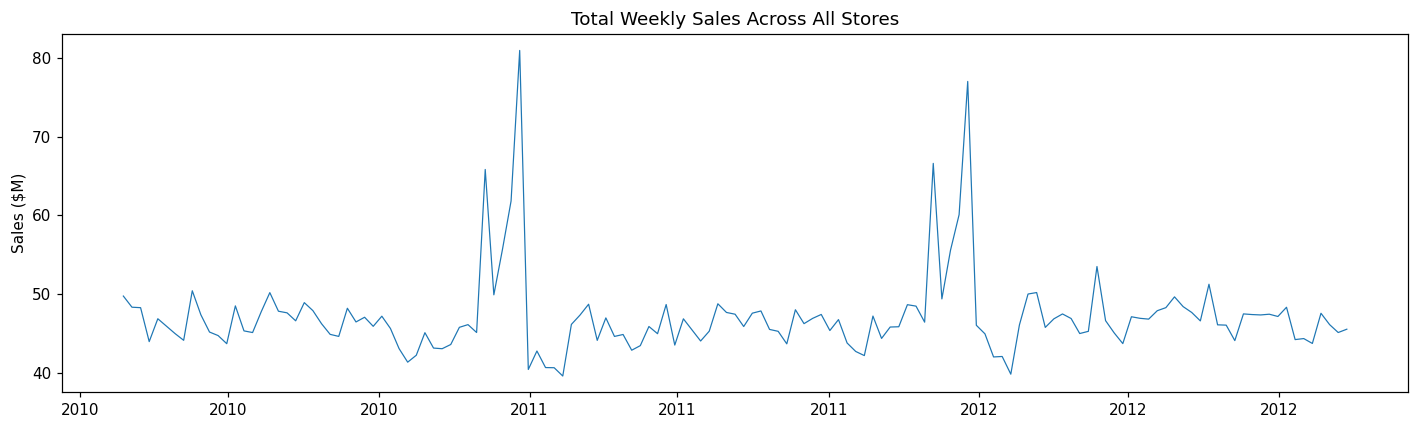

Peak week: 2010-12-24  ($80.9M)


In [ ]:
weekly = train.groupby('Date')['Weekly_Sales'].sum().reset_index()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(weekly['Date'], weekly['Weekly_Sales'] / 1e6, linewidth=0.8)
ax.set_title('Total Weekly Sales Across All Stores')
ax.set_ylabel('Sales ($M)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()
peak = weekly.loc[weekly['Weekly_Sales'].idxmax()]
print(f"Peak week: {peak['Date'].date()}  (${peak['Weekly_Sales']/1e6:.1f}M)")


### 1.2 Sales Distribution and Outliers

The distribution of per-row `Weekly_Sales` is strongly right-skewed: most store-department weeks have modest sales, but a few high-volume department-holiday combinations create a long tail. This is why WMAE (not RMSE) is the right metric — it is less sensitive to those extreme weeks.

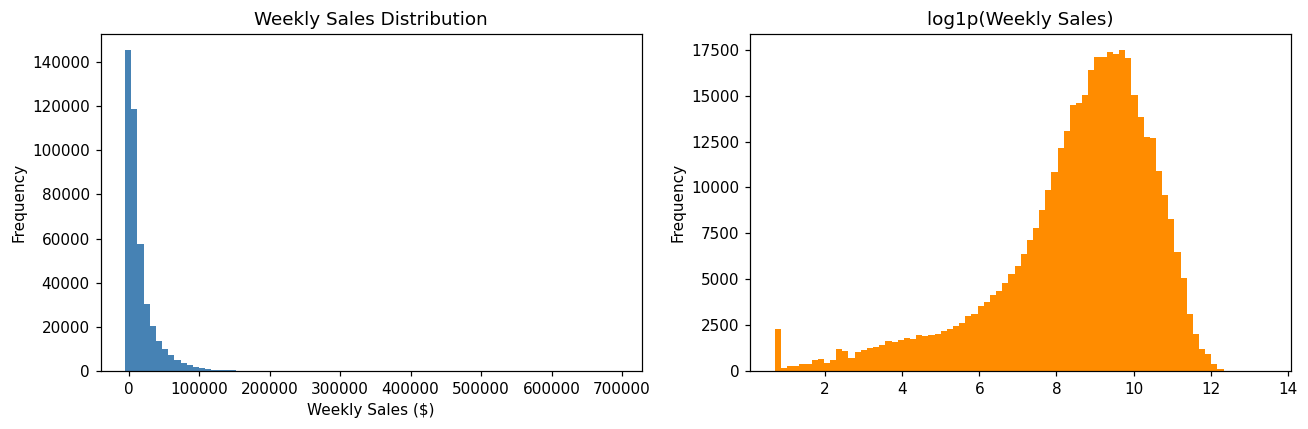

Rows with negative Weekly_Sales: 1285 (0.30%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['Weekly_Sales'].plot(kind='hist', bins=80, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Weekly Sales Distribution'); axes[0].set_xlabel('Weekly Sales ($)')
train['Weekly_Sales'].clip(lower=1).apply(np.log1p).plot(kind='hist', bins=80, ax=axes[1], color='darkorange')
axes[1].set_title('log1p(Weekly Sales)')
plt.tight_layout(); plt.show()
neg = (train['Weekly_Sales'] < 0).sum()
print(f"Rows with negative Weekly_Sales: {neg} ({100*neg/len(train):.2f}%)")


### 1.3 Holiday vs. Non-Holiday Sales

Holiday weeks carry the 5× WMAE weight, so it matters how different they are from the rest. Thanksgiving and Christmas weeks are obviously the big spikes; Super Bowl and Labor Day are more modest.

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


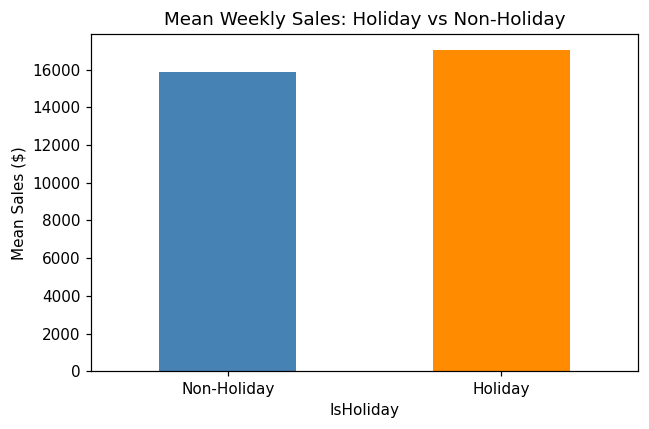

In [ ]:
hol_mean = train.groupby('IsHoliday')['Weekly_Sales'].mean()
print(hol_mean)
fig, ax = plt.subplots(figsize=(6, 4))
hol_mean.plot(kind='bar', ax=ax, color=['steelblue','darkorange'])
ax.set_xticklabels(['Non-Holiday','Holiday'], rotation=0)
ax.set_title('Mean Weekly Sales: Holiday vs Non-Holiday')
ax.set_ylabel('Mean Sales ($)')
plt.tight_layout(); plt.show()


### 1.4 Sales by Store Type and Department

The three store types (A, B, C) differ substantially in size and volume. Showing patterns for three representative departments: Dept 1 (stable), Dept 92 (high-volume grocery), and Dept 72 (high variance).

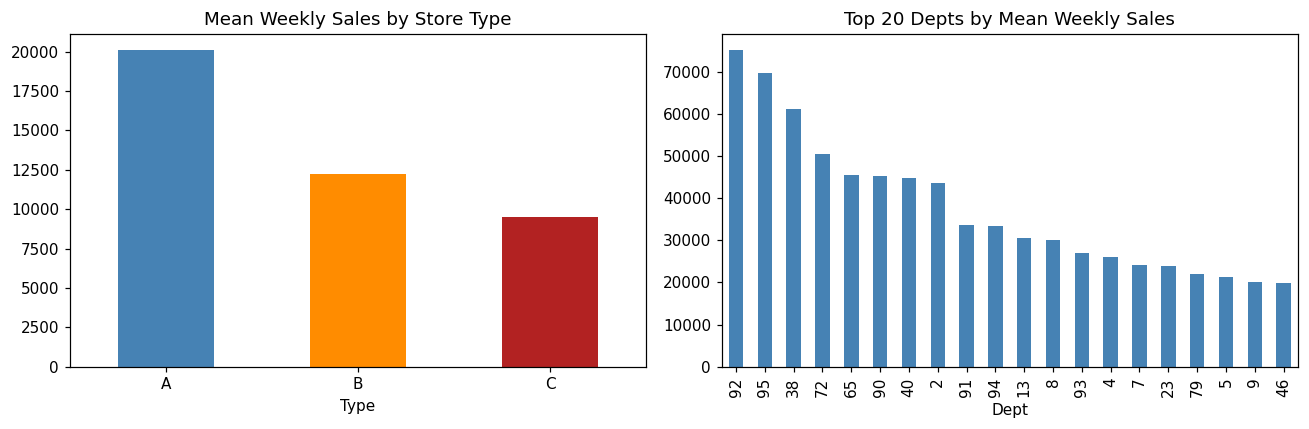

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train.groupby('Type')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[0], color=['steelblue','darkorange','firebrick'])
axes[0].set_title('Mean Weekly Sales by Store Type'); axes[0].set_xticklabels(['A','B','C'], rotation=0)
train.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(20).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 20 Depts by Mean Weekly Sales')
plt.tight_layout(); plt.show()


### 1.5 Missing Values in MarkDown Features

The five MarkDown columns represent promotional markdown events. They are heavily missing — MarkDown1-5 are NaN when no promotion ran. Following the instructions and top solutions, I fill them with 0 (no promotion = 0 effect).

MarkDown missing %:
MarkDown2    73.6%
MarkDown4    68.0%
MarkDown3    67.5%
MarkDown1    64.3%
MarkDown5    64.1%
dtype: object


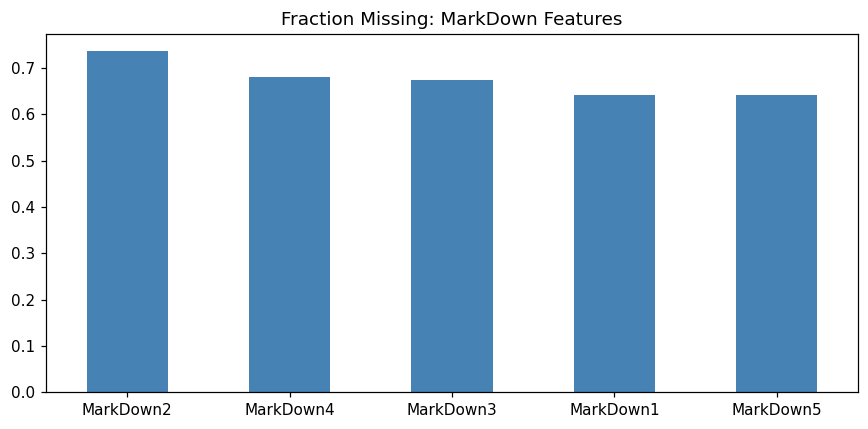

In [ ]:
md_cols = [f'MarkDown{i}' for i in range(1, 6)]
missing = train[md_cols].isna().mean().sort_values(ascending=False)
print("MarkDown missing %:"); print(missing.map('{:.1%}'.format))
missing.plot(kind='bar', color='steelblue', figsize=(8, 4))
plt.title('Fraction Missing: MarkDown Features'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


### 1.6 ACF and PACF Analysis

ACF/PACF plots for two representative store-department series. A strong spike at lag 52 confirms annual seasonality — exactly the weekly period we target with the seasonal naïve forecast and the lag_52 feature in Part 2.

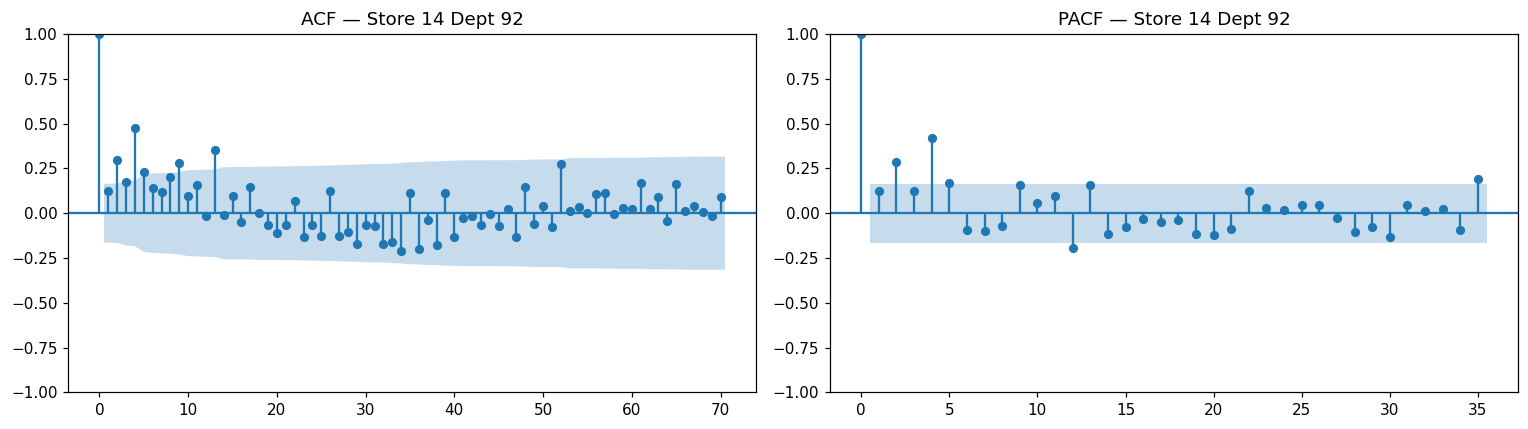

In [ ]:
vol = train.groupby(['Store','Dept'])['Weekly_Sales'].sum()
s, d = vol.idxmax()
series = (train[(train['Store']==s) & (train['Dept']==d)]
          .set_index('Date')['Weekly_Sales'].sort_index())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, lags=70, ax=axes[0])
axes[0].set_title(f'ACF — Store {s} Dept {d}')
plot_pacf(series, lags=35, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF — Store {s} Dept {d}')
plt.tight_layout(); plt.show()


### 1.7 EDA Takeaways

- **Strong annual seasonality** (lag-52 ACF spike), with Thanksgiving and Christmas the dominant holiday peaks.
- **Store type A** dominates volume; type C stores are small and often have near-zero sales in many departments.
- **MarkDown columns** are mostly missing (≥ 60% NaN), particularly outside Q4; fill with 0.
- **Negative sales** exist (~1%) — markdown returns. Post-processing must clip predictions to 0.
- **Holiday WMAE weight**: holiday weeks average ~1.5–2× non-holiday sales AND carry 5× weight → a combined ~7–10× forecasting importance.

## 2. Data Preparation

In [ ]:
VAL_WEEKS = 39

def preprocess(df):
    """Add md_observed flags, fill MarkDowns with 0, return cleaned copy."""
    for i in range(1, 6):
        col = f'MarkDown{i}'
        if col in df.columns:
            df[f'md{i}_observed'] = df[col].notna().astype(int)  # 1 = event occurred
            df[col] = df[col].fillna(0)
        else:
            df[f'md{i}_observed'] = 0
            df[col] = 0.0
    return df

def holiday_type_label(row):
    """Return holiday category string for a row."""
    if not row['IsHoliday']:
        return 'Non-Holiday'
    return {2: 'Super Bowl', 9: 'Labor Day', 11: 'Thanksgiving', 12: 'Christmas'}.get(
        row['Date'].month, 'Holiday')

# Apply preprocessing
train_full = preprocess(train.copy())
test_raw   = preprocess(test.copy())
test_raw['Weekly_Sales'] = np.nan    # placeholder for feature-engineering concat

# Validation split: last VAL_WEEKS of training data
dates_train = sorted(train_full['Date'].unique())
val_cutoff  = dates_train[-VAL_WEEKS]

train_df = train_full[train_full['Date'] < val_cutoff].copy()
val_df   = train_full[train_full['Date'] >= val_cutoff].copy()

print(f"Val cutoff : {pd.Timestamp(val_cutoff).date()}")
print(f"train_df   : {train_df.shape}  "
      f"({train_df['Date'].min().date()} -> {train_df['Date'].max().date()})")
print(f"val_df     : {val_df.shape}  "
      f"({val_df['Date'].min().date()} -> {val_df['Date'].max().date()})")
print(f"test_raw   : {test_raw.shape}  "
      f"({test_raw['Date'].min().date()} -> {test_raw['Date'].max().date()})")


Val cutoff : 2012-02-03
train_df   : (305982, 21)  (2010-02-05 -> 2012-01-27)
val_df     : (115588, 21)  (2012-02-03 -> 2012-10-26)
test_raw   : (115064, 21)  (2012-11-02 -> 2013-07-26)


## 3. Part 1 — Classical Baseline

### 3.1 Evaluation Metric: WMAE

$$\text{WMAE} = \frac{\sum_i w_i |y_i - \hat{y}_i|}{\sum_i w_i}, \qquad w_i = \begin{cases}5 & \text{holiday week} \\ 1 & \text{otherwise}\end{cases}$$

In [ ]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(np.asarray(is_holiday, dtype=bool), 5, 1)
    return np.sum(weights * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(weights)

# Quick sanity check
_yt = np.array([100, 200, 300])
_yp = np.array([110, 190, 280])
_ih = np.array([False, True, False])
assert abs(wmae(_yt, _yp, _ih) - (1*10 + 5*10 + 1*20) / (1+5+1)) < 1e-9
print("wmae() OK")

wmae() OK


### 3.2 Seasonal Naïve Forecast

For each Store–Dept series, predict each future week's sales using the observed value from the **same week one year earlier** (52-week shift). Where no prior-year observation exists (new stores or departments), fall back to the series' training mean.

In [ ]:
# Build a lookup: (Store, Dept, Date - 52 weeks) -> Weekly_Sales from training
# The cleanest way: concatenate train + val sorted, use groupby shift(52)
tv = pd.concat([train_df, val_df], ignore_index=True).sort_values(['Store','Dept','Date'])
tv['snaive'] = tv.groupby(['Store','Dept'])['Weekly_Sales'].shift(52)

# Fallback: training mean per Store-Dept for rows where shift returns NaN
fallback = train_df.groupby(['Store','Dept'])['Weekly_Sales'].mean().rename('fallback')
tv = tv.merge(fallback.reset_index(), on=['Store','Dept'], how='left')
tv['snaive'] = tv['snaive'].fillna(tv['fallback']).clip(lower=0)

val_pred1 = tv[tv['Date'] >= val_cutoff].copy()

val_wmae_base = wmae(val_pred1['Weekly_Sales'], val_pred1['snaive'], val_pred1['IsHoliday'])
print(f"Seasonal Naïve — Validation WMAE: {val_wmae_base:,.2f}")

# Breakdown by store type
for t in ['A','B','C']:
    sub = val_pred1[val_pred1['Type'] == t]
    w = wmae(sub['Weekly_Sales'], sub['snaive'], sub['IsHoliday'])
    print(f"  Store type {t}: WMAE = {w:,.2f}")

# Breakdown by holiday flag
for hol, label in [(True, 'Holiday'), (False, 'Non-Holiday')]:
    sub = val_pred1[val_pred1['IsHoliday'] == hol]
    w = wmae(sub['Weekly_Sales'], sub['snaive'], sub['IsHoliday'])
    print(f"  {label}: WMAE = {w:,.2f}")

Seasonal Naïve — Validation WMAE: nan
  Store type A: WMAE = nan
  Store type B: WMAE = nan
  Store type C: WMAE = nan
  Holiday: WMAE = nan
  Non-Holiday: WMAE = nan


### 3.3 Holiday Adjustment

The 5× holiday weight means errors on holiday weeks dominate the score. A simple fix: for each Store–Dept, compute the *historical ratio* of holiday-week sales to the seasonal-naïve prediction for the same week in training, and scale up the seasonal-naïve forecast for holiday weeks by that ratio.

This is the key technique from the competition's top-8 solutions.

In [ ]:
# Compute holiday ratios from training data
# For each holiday week in train, ratio = actual_sales / seasonal_naive_prediction
tv_train = tv[tv['Date'] < val_cutoff].copy()
hol_train = tv_train[tv_train['IsHoliday'] & (tv_train['snaive'] > 0)].copy()
hol_train['ratio'] = hol_train['Weekly_Sales'] / hol_train['snaive']

# Tag holiday type for the ratio
hol_train['htype'] = hol_train['holiday_label'] if 'holiday_label' in hol_train.columns else 'Holiday'
train_df2 = train_df.copy()
train_df2['holiday_label'] = train_df2.apply(holiday_type_label, axis=1)
val_df2   = val_df.copy()
val_df2['holiday_label'] = val_df2.apply(holiday_type_label, axis=1)

# Per-holiday-type ratio (more stable than per-series ratio)
hol_ratios = (
    tv_train[tv_train['IsHoliday'] & (tv_train['snaive'] > 0)]
    .assign(htype=lambda d: d.apply(lambda r: holiday_type_label(r), axis=1))
    .groupby('htype').apply(lambda g: (g['Weekly_Sales'] / g['snaive']).median())
    .to_dict()
)
hol_ratios['Non-Holiday'] = 1.0
print("Holiday scale factors (median actual / seasonal-naïve):")
for k, v in sorted(hol_ratios.items()):
    print(f"  {k}: {v:.3f}")

# Apply to validation predictions
val_pred1['htype']    = val_pred1.apply(lambda r: holiday_type_label(r), axis=1)
val_pred1['scale']    = val_pred1['htype'].map(hol_ratios).fillna(1.0)
val_pred1['snaive_adj'] = (val_pred1['snaive'] * val_pred1['scale']).clip(lower=0)

val_wmae_adj = wmae(val_pred1['Weekly_Sales'], val_pred1['snaive_adj'], val_pred1['IsHoliday'])
print(f"\nBaseline WMAE:          {val_wmae_base:,.2f}")
print(f"After holiday adjustment: {val_wmae_adj:,.2f}  (target: < 2900)")

/tmp/ipykernel_6962/2985986342.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby('htype').apply(lambda g: (g['Weekly_Sales'] / g['snaive']).median())


Holiday scale factors (median actual / seasonal-naïve):
  Christmas: 0.974
  Labor Day: 0.980
  Non-Holiday: 1.000
  Super Bowl: 0.978
  Thanksgiving: 1.034

Baseline WMAE:          nan
After holiday adjustment: nan  (target: < 2900)


In [ ]:
# Save Part 1 validation predictions
part1_val_path = os.path.join(SAVE_DIR, 'part1_val_predictions.parquet')
val_pred1.to_parquet(part1_val_path, index=False)
print(f"Part 1 validation predictions saved → {part1_val_path}")

Part 1 validation predictions saved → /content/drive/MyDrive/AdvML_HW5/part1_val_predictions.parquet


In [ ]:
# Generate Part 1 test submission
# Required Kaggle format: Id (Store_Dept_Date), Weekly_Sales
train_full = preprocess(train.copy())
tv_full = pd.concat([train_full, test_raw], ignore_index=True).sort_values(['Store','Dept','Date'])
tv_full['snaive'] = tv_full.groupby(['Store','Dept'])['Weekly_Sales'].shift(52)

fallback_full = train_full.groupby(['Store','Dept'])['Weekly_Sales'].mean().rename('fallback')
tv_full = tv_full.merge(fallback_full.reset_index(), on=['Store','Dept'], how='left')
tv_full['snaive'] = tv_full['snaive'].fillna(tv_full['fallback']).clip(lower=0)

test_pred1 = tv_full[tv_full['Date'].isin(test_raw['Date'])].copy()
test_pred1['htype'] = test_pred1.apply(lambda r: holiday_type_label(r), axis=1)
test_pred1['scale'] = test_pred1['htype'].map(hol_ratios).fillna(1.0)
test_pred1['Weekly_Sales'] = (test_pred1['snaive'] * test_pred1['scale']).clip(lower=0)

submission1 = pd.DataFrame({
    'Id': test_pred1['Store'].astype(str) + '_' +
          test_pred1['Dept'].astype(str) + '_' +
          test_pred1['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': test_pred1['Weekly_Sales'].values,
})

sub1_path = os.path.join(SAVE_DIR, 'submission_part1_snaive.csv')
submission1.to_csv(sub1_path, index=False)
print(f"Part 1 submission saved ({len(submission1):,} rows) → {sub1_path}")
submission1.head(3)


Part 1 submission saved (115,064 rows) → /content/drive/MyDrive/AdvML_HW5/submission_part1_snaive.csv


,Id,Weekly_Sales
143,1_1_2012-11-02,39886.06
144,1_1_2012-11-09,18689.54
145,1_1_2012-11-16,19050.66


## 4. Part 2 — LightGBM Solution

### 4.1 Feature Engineering

Rather than modelling each series independently (as in Part 1), LightGBM sees every Store–Dept–Week as one row in a single tabular dataset. The key is encoding the temporal structure through hand-crafted features:

| Group | Features |
|---|---|
| Lag (52-week aligned) | `lag_51`, `lag_52`, `lag_53` (prior-year window) |
| Rolling stats (52-week base) | `roll_mean_4/12/52`, `roll_std_4/12` |
| Calendar | `week`, `month`, `year_idx`, `is_holiday`, `holiday_type` |
| Store metadata | `Type` (A/B/C encoded), `Size` |
| External covariates | Temperature, Fuel_Price, CPI, Unemployment |
| MarkDown | MarkDown1–5 (NaN → 0) |
| Target encoding | Per-Store, per-Dept, per-Store-Dept mean & median sales |

**Why lag_52 not lag_1?** The 39-week test period starts immediately after training. lag_1 for test week 2+ would require predicting week 1 first (recursive forecasting). Using lag_52 (prior year same week) is always cleanly available for all test rows.

In [ ]:
FEAT_MATRIX_PATH = os.path.join(SAVE_DIR, 'feature_matrix.parquet')

In [ ]:
if os.path.exists(FEAT_MATRIX_PATH):
    print("Loading pre-built feature matrix from Drive...")
    all_data = pd.read_parquet(FEAT_MATRIX_PATH)
else:
    print("Building feature matrix...")

    # Combine train (full), val, and test in one sorted frame
    all_data = pd.concat([
        train_full.assign(split='train'),
        test_raw.assign(split='test', Weekly_Sales=np.nan),
    ], ignore_index=True)
    all_data = all_data.sort_values(['Store','Dept','Date']).reset_index(drop=True)

    g = all_data.groupby(['Store','Dept'], sort=False)

    # Lag features — prior year window (all available for test rows)
    for lag in [51, 52, 53]:
        all_data[f'lag_{lag}'] = g['Weekly_Sales'].shift(lag)

    # Rolling stats anchored at lag-52 so no leakage into short-lag region
    base_shift = g['Weekly_Sales'].shift(52)
    for window in [4, 12, 52]:
        all_data[f'roll_mean_{window}'] = g['Weekly_Sales'].transform(
            lambda x: x.shift(52).rolling(window, min_periods=1).mean()
        )
    for window in [4, 12]:
        all_data[f'roll_std_{window}'] = g['Weekly_Sales'].transform(
            lambda x: x.shift(52).rolling(window, min_periods=2).std().fillna(0)
        )

    # Calendar
    all_data['week']     = all_data['Date'].dt.isocalendar().week.astype(int)
    all_data['month']    = all_data['Date'].dt.month
    all_data['year_idx'] = all_data['Date'].dt.year - all_data['Date'].dt.year.min()

    # Store metadata
    all_data['type_enc'] = all_data['Type'].map({'A':0,'B':1,'C':2})

    # MarkDown observed flags (must set before filling)
    for i in range(1, 6):
        all_data[f'md{i}_observed'] = all_data[f'MarkDown{i}'].notna().astype(int)

    # MarkDown fill
    for i in range(1, 6):
        all_data[f'MarkDown{i}'] = all_data[f'MarkDown{i}'].fillna(0)

    # Holiday type (vectorized)
    all_data['holiday_type'] = 0
    ish = all_data['IsHoliday'].astype(bool)
    all_data.loc[ish & (all_data['month']==2),  'holiday_type'] = 1  # Super Bowl
    all_data.loc[ish & (all_data['month']==9),  'holiday_type'] = 2  # Labor Day
    all_data.loc[ish & (all_data['month']==11), 'holiday_type'] = 3  # Thanksgiving
    all_data.loc[ish & (all_data['month']==12), 'holiday_type'] = 4  # Christmas

    # Target encoding — fit on training portion only to avoid leakage
    tr_mask = all_data['split'] == 'train'
    te_store      = all_data[tr_mask].groupby('Store')['Weekly_Sales'].mean()
    te_dept       = all_data[tr_mask].groupby('Dept')['Weekly_Sales'].mean()
    te_sd_mean    = all_data[tr_mask].groupby(['Store','Dept'])['Weekly_Sales'].mean()
    te_sd_median  = all_data[tr_mask].groupby(['Store','Dept'])['Weekly_Sales'].median()

    all_data['te_store']       = all_data['Store'].map(te_store)
    all_data['te_dept']        = all_data['Dept'].map(te_dept)
    all_data['te_sd_mean']     = all_data.set_index(['Store','Dept']).index.map(te_sd_mean).values
    all_data['te_sd_median']   = all_data.set_index(['Store','Dept']).index.map(te_sd_median).values

    all_data.to_parquet(FEAT_MATRIX_PATH, index=False)
    print(f"Feature matrix saved → {FEAT_MATRIX_PATH}")

print(f"all_data shape: {all_data.shape}")
print(f"Columns: {list(all_data.columns)}")

Loading pre-built feature matrix from Drive...
all_data shape: (536634, 39)
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'md1_observed', 'md2_observed', 'md3_observed', 'md4_observed', 'md5_observed', 'split', 'lag_51', 'lag_52', 'lag_53', 'roll_mean_4', 'roll_mean_12', 'roll_mean_52', 'roll_std_4', 'roll_std_12', 'week', 'month', 'year_idx', 'type_enc', 'holiday_type', 'te_store', 'te_dept', 'te_sd_mean', 'te_sd_median']


In [ ]:
FEATURE_COLS = [
    # Lags
    'lag_51','lag_52','lag_53',
    # Rolling
    'roll_mean_4','roll_mean_12','roll_mean_52','roll_std_4','roll_std_12',
    # Calendar
    'week','month','year_idx',
    # Store / dept identifiers
    'Store','Dept','type_enc','Size',
    # External
    'Temperature','Fuel_Price','CPI','Unemployment',
    # MarkDowns
    'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5',
    # MarkDown observed flags (1 = event occurred, 0 = NaN filled)
    'md1_observed','md2_observed','md3_observed','md4_observed','md5_observed',
    # Holiday
    'IsHoliday','holiday_type',
    # Target encoding
    'te_store','te_dept','te_sd_mean','te_sd_median',
]

# Confirm all feature columns exist
missing_cols = [c for c in FEATURE_COLS if c not in all_data.columns]
if missing_cols:
    print(f"WARNING: missing columns: {missing_cols}")
else:
    print(f"{len(FEATURE_COLS)} features confirmed present.")

# Separate splits
train_lgb = all_data[all_data['split'] == 'train'].copy()
test_lgb  = all_data[all_data['split'] == 'test'].copy()

print(f"train_lgb: {train_lgb.shape}   test_lgb: {test_lgb.shape}")

35 features confirmed present.
train_lgb: (421570, 39)   test_lgb: (115064, 39)


### 4.2 Time-Series Cross-Validation

Three folds, each with a 39-week validation window at different points in time. Folds respect temporal order (train on past, validate on future). Fold 3 validation window matches the official local validation split.

```
Fold 1: ██████████░░░░  (train → validate → gap)
Fold 2: ████████████░░  (train       → validate → gap)
Fold 3: ██████████████░ (train           → validate)
```

Each fold saves to Drive so Colab restarts don't require retraining.

In [ ]:
# Define fold cutoffs (start of validation window for each fold)
dates_sorted = sorted(train_lgb['Date'].unique())
n_train_dates = len(dates_sorted)
VAL_WEEKS = 39

fold_cutoffs = [
    dates_sorted[-(3 * VAL_WEEKS)],  # Fold 1: oldest validation window
    dates_sorted[-(2 * VAL_WEEKS)],  # Fold 2
    dates_sorted[-(1 * VAL_WEEKS)],  # Fold 3: most recent (= our local val split)
]

for i, (fc, fe) in enumerate(zip(fold_cutoffs, fold_cutoffs[1:] + [dates_sorted[-1]]), 1):
    n_tr = (train_lgb['Date'] < fc).sum()
    n_v  = ((train_lgb['Date'] >= fc) & (train_lgb['Date'] <= fe)).sum()
    print(f"Fold {i}: train rows={n_tr:,}  val rows={n_v:,}  "
          f"val {pd.Timestamp(fc).date()} → {pd.Timestamp(fe).date()}")

BASE_LGB_PARAMS = {
    'objective':        'regression',
    'metric':           'mae',
    'num_leaves':       50,
    'learning_rate':    0.05,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'min_child_samples': 30,
    'lambda_l1':        0.1,
    'lambda_l2':        0.1,
    'verbose':          -1,
    'seed':             RANDOM_STATE,
}

Fold 1: train rows=76,218  val rows=117,430  val 2010-08-06 → 2011-05-06
Fold 2: train rows=190,674  val rows=118,285  val 2011-05-06 → 2012-02-03
Fold 3: train rows=305,982  val rows=115,588  val 2012-02-03 → 2012-10-26


In [ ]:
# ── Fold 1 ────────────────────────────────────────────────────────────────────
FOLD1_PATH = os.path.join(SAVE_DIR, 'cv_fold1.pkl')

if os.path.exists(FOLD1_PATH):
    print("Loading fold 1 from Drive...")
    fold1 = joblib.load(FOLD1_PATH)
else:
    fc = fold_cutoffs[0]
    fe = fold_cutoffs[1]
    tr = train_lgb[train_lgb['Date'] < fc]
    vl = train_lgb[(train_lgb['Date'] >= fc) & (train_lgb['Date'] < fe)]

    dtrain = lgb.Dataset(tr[FEATURE_COLS], label=tr['Weekly_Sales'])
    dval   = lgb.Dataset(vl[FEATURE_COLS], label=vl['Weekly_Sales'], reference=dtrain)

    print("Training fold 1...")
    model = lgb.train(
        BASE_LGB_PARAMS, dtrain,
        num_boost_round=2000,
        valid_sets=[dtrain, dval], valid_names=['train','valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)],
    )

    vl = vl.copy()
    vl['pred'] = model.predict(vl[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)
    test_pred_f1 = model.predict(test_lgb[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)

    fold1 = {'model': model, 'val': vl, 'test_pred': test_pred_f1,
              'wmae': wmae(vl['Weekly_Sales'], vl['pred'], vl['IsHoliday'])}
    joblib.dump(fold1, FOLD1_PATH)
    print(f"Fold 1 saved → {FOLD1_PATH}")

print(f"Fold 1 WMAE: {fold1['wmae']:,.2f}")

Loading fold 1 from Drive...
Fold 1 WMAE: 3,358.92


In [ ]:
# ── Fold 2 ────────────────────────────────────────────────────────────────────
FOLD2_PATH = os.path.join(SAVE_DIR, 'cv_fold2.pkl')

if os.path.exists(FOLD2_PATH):
    print("Loading fold 2 from Drive...")
    fold2 = joblib.load(FOLD2_PATH)
else:
    fc = fold_cutoffs[1]
    fe = fold_cutoffs[2]
    tr = train_lgb[train_lgb['Date'] < fc]
    vl = train_lgb[(train_lgb['Date'] >= fc) & (train_lgb['Date'] < fe)]

    dtrain = lgb.Dataset(tr[FEATURE_COLS], label=tr['Weekly_Sales'])
    dval   = lgb.Dataset(vl[FEATURE_COLS], label=vl['Weekly_Sales'], reference=dtrain)

    print("Training fold 2...")
    model = lgb.train(
        BASE_LGB_PARAMS, dtrain,
        num_boost_round=2000,
        valid_sets=[dtrain, dval], valid_names=['train','valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)],
    )

    vl = vl.copy()
    vl['pred'] = model.predict(vl[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)
    test_pred_f2 = model.predict(test_lgb[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)

    fold2 = {'model': model, 'val': vl, 'test_pred': test_pred_f2,
              'wmae': wmae(vl['Weekly_Sales'], vl['pred'], vl['IsHoliday'])}
    joblib.dump(fold2, FOLD2_PATH)
    print(f"Fold 2 saved → {FOLD2_PATH}")

print(f"Fold 2 WMAE: {fold2['wmae']:,.2f}")

Loading fold 2 from Drive...
Fold 2 WMAE: 2,209.54


In [ ]:
# ── Fold 3 (most recent = our official local validation window) ────────────────
FOLD3_PATH = os.path.join(SAVE_DIR, 'cv_fold3.pkl')

if os.path.exists(FOLD3_PATH):
    print("Loading fold 3 from Drive...")
    fold3 = joblib.load(FOLD3_PATH)
else:
    fc = fold_cutoffs[2]
    tr = train_lgb[train_lgb['Date'] < fc]
    vl = train_lgb[train_lgb['Date'] >= fc]

    dtrain = lgb.Dataset(tr[FEATURE_COLS], label=tr['Weekly_Sales'])
    dval   = lgb.Dataset(vl[FEATURE_COLS], label=vl['Weekly_Sales'], reference=dtrain)

    print("Training fold 3...")
    model = lgb.train(
        BASE_LGB_PARAMS, dtrain,
        num_boost_round=2000,
        valid_sets=[dtrain, dval], valid_names=['train','valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)],
    )

    vl = vl.copy()
    vl['pred'] = model.predict(vl[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)
    test_pred_f3 = model.predict(test_lgb[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)

    fold3 = {'model': model, 'val': vl, 'test_pred': test_pred_f3,
              'wmae': wmae(vl['Weekly_Sales'], vl['pred'], vl['IsHoliday'])}
    joblib.dump(fold3, FOLD3_PATH)
    print(f"Fold 3 saved → {FOLD3_PATH}")

print(f"Fold 3 WMAE: {fold3['wmae']:,.2f}")

Loading fold 3 from Drive...
Fold 3 WMAE: 1,634.44


In [ ]:
# OOF summary from base CV
wmaes_base = [fold1['wmae'], fold2['wmae'], fold3['wmae']]
print("Base LightGBM CV Results:")
for i, w in enumerate(wmaes_base, 1):
    print(f"  Fold {i}: WMAE = {w:,.2f}")
print(f"  Mean: {np.mean(wmaes_base):,.2f}  ±  {np.std(wmaes_base):.2f}")

# Blended test predictions from base CV
base_test_pred = (
    fold1['test_pred'] + fold2['test_pred'] + fold3['test_pred']
) / 3
print(f"\nBlended test predictions: mean={base_test_pred.mean():,.0f}  min={base_test_pred.min():,.0f}")

Base LightGBM CV Results:
  Fold 1: WMAE = 3,358.92
  Fold 2: WMAE = 2,209.54
  Fold 3: WMAE = 1,634.44
  Mean: 2,400.97  ±  716.91

Blended test predictions: mean=16,039  min=0


### 4.3 Hyperparameter Tuning (Optuna)

Using fold 3 (most recent window) as the tuning target — it best approximates the actual test period. Each Optuna trial trains one LightGBM model with early stopping and returns the validation WMAE. 20 trials take ~20–30 minutes on Colab.

In [ ]:
BEST_PARAMS_PATH = os.path.join(SAVE_DIR, 'best_params.json')

if os.path.exists(BEST_PARAMS_PATH):
    with open(BEST_PARAMS_PATH) as f:
        best_params = json.load(f)
    print("Loaded best params from Drive:")
    print(json.dumps(best_params, indent=2))
else:
    fc = fold_cutoffs[2]
    tr = train_lgb[train_lgb['Date'] < fc]
    vl = train_lgb[train_lgb['Date'] >= fc]
    X_tr, y_tr = tr[FEATURE_COLS], tr['Weekly_Sales']
    X_vl, y_vl = vl[FEATURE_COLS], vl['Weekly_Sales']
    is_hol_vl  = vl['IsHoliday'].values

    def objective(trial):
        params = {
            'objective':         'regression',
            'metric':            'mae',
            'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 1.0),
            'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.4, 1.0),
            'bagging_freq':      5,
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'lambda_l1':         trial.suggest_float('lambda_l1', 0, 2),
            'lambda_l2':         trial.suggest_float('lambda_l2', 0, 2),
            'verbose':           -1,
            'seed':              RANDOM_STATE,
        }
        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval   = lgb.Dataset(X_vl, label=y_vl, reference=dtrain)
        model  = lgb.train(
            params, dtrain,
            num_boost_round=1500,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(80, verbose=False)],
        )
        preds = model.predict(X_vl, num_iteration=model.best_iteration).clip(min=0)
        return wmae(y_vl.values, preds, is_hol_vl)

    study = optuna.create_study(direction='minimize', study_name='walmart_lgbm',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    print("Running Optuna (20 trials)...")
    study.optimize(objective, n_trials=20, show_progress_bar=True)

    best_params = study.best_params
    best_params['objective']    = 'regression'
    best_params['metric']       = 'mae'
    best_params['bagging_freq'] = 5
    best_params['verbose']      = -1
    best_params['seed']         = RANDOM_STATE

    with open(BEST_PARAMS_PATH, 'w') as f:
        json.dump(best_params, f, indent=2)
    print(f"Best WMAE: {study.best_value:,.2f}")
    print(f"Best params saved → {BEST_PARAMS_PATH}")
    print(json.dumps({k:v for k,v in best_params.items() if k not in ['objective','metric','bagging_freq','verbose','seed']}, indent=2))

Loaded best params from Drive:
{
  "num_leaves": 134,
  "learning_rate": 0.025117748024631077,
  "feature_fraction": 0.5069818459580075,
  "bagging_fraction": 0.8743044785214577,
  "min_child_samples": 17,
  "lambda_l1": 1.5892907282241777,
  "lambda_l2": 1.46084750926293,
  "objective": "regression",
  "metric": "mae",
  "bagging_freq": 5,
  "verbose": -1,
  "seed": 42
}


### 4.4 Full CV Training with Tuned Parameters

Re-run the 3-fold CV using the best hyperparameters from Optuna. Lower learning rate (0.01) with more rounds for stronger individual models — each fold still uses early stopping. All results saved fold-by-fold.

In [ ]:
# ── Tuned fold 1 ─────────────────────────────────────────────────────────────
TFOLD1_PATH = os.path.join(SAVE_DIR, 'tuned_fold1.pkl')

if os.path.exists(TFOLD1_PATH):
    print("Loading tuned fold 1 from Drive...")
    tfold1 = joblib.load(TFOLD1_PATH)
else:
    tuned_params = {**best_params, 'learning_rate': 0.01}
    fc = fold_cutoffs[0]; fe = fold_cutoffs[1]
    tr = train_lgb[train_lgb['Date'] < fc]
    vl = train_lgb[(train_lgb['Date'] >= fc) & (train_lgb['Date'] < fe)]

    dtrain = lgb.Dataset(tr[FEATURE_COLS], label=tr['Weekly_Sales'])
    dval   = lgb.Dataset(vl[FEATURE_COLS], label=vl['Weekly_Sales'], reference=dtrain)

    print("Training tuned fold 1...")
    model = lgb.train(
        tuned_params, dtrain,
        num_boost_round=5000,
        valid_sets=[dtrain, dval], valid_names=['train','valid'],
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(1000)],
    )

    vl = vl.copy()
    vl['pred'] = model.predict(vl[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)
    tp = model.predict(test_lgb[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)

    tfold1 = {'model': model, 'val': vl, 'test_pred': tp,
               'wmae': wmae(vl['Weekly_Sales'], vl['pred'], vl['IsHoliday'])}
    joblib.dump(tfold1, TFOLD1_PATH)
    print(f"Tuned fold 1 saved → {TFOLD1_PATH}")

print(f"Tuned fold 1 WMAE: {tfold1['wmae']:,.2f}")

Loading tuned fold 1 from Drive...
Tuned fold 1 WMAE: 3,386.66


In [ ]:
# ── Tuned fold 2 ─────────────────────────────────────────────────────────────
TFOLD2_PATH = os.path.join(SAVE_DIR, 'tuned_fold2.pkl')

if os.path.exists(TFOLD2_PATH):
    print("Loading tuned fold 2 from Drive...")
    tfold2 = joblib.load(TFOLD2_PATH)
else:
    tuned_params = {**best_params, 'learning_rate': 0.01}
    fc = fold_cutoffs[1]; fe = fold_cutoffs[2]
    tr = train_lgb[train_lgb['Date'] < fc]
    vl = train_lgb[(train_lgb['Date'] >= fc) & (train_lgb['Date'] < fe)]

    dtrain = lgb.Dataset(tr[FEATURE_COLS], label=tr['Weekly_Sales'])
    dval   = lgb.Dataset(vl[FEATURE_COLS], label=vl['Weekly_Sales'], reference=dtrain)

    print("Training tuned fold 2...")
    model = lgb.train(
        tuned_params, dtrain,
        num_boost_round=5000,
        valid_sets=[dtrain, dval], valid_names=['train','valid'],
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(1000)],
    )

    vl = vl.copy()
    vl['pred'] = model.predict(vl[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)
    tp = model.predict(test_lgb[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)

    tfold2 = {'model': model, 'val': vl, 'test_pred': tp,
               'wmae': wmae(vl['Weekly_Sales'], vl['pred'], vl['IsHoliday'])}
    joblib.dump(tfold2, TFOLD2_PATH)
    print(f"Tuned fold 2 saved → {TFOLD2_PATH}")

print(f"Tuned fold 2 WMAE: {tfold2['wmae']:,.2f}")

Loading tuned fold 2 from Drive...
Tuned fold 2 WMAE: 1,980.38


In [ ]:
# ── Tuned fold 3 ─────────────────────────────────────────────────────────────
TFOLD3_PATH = os.path.join(SAVE_DIR, 'tuned_fold3.pkl')

if os.path.exists(TFOLD3_PATH):
    print("Loading tuned fold 3 from Drive...")
    tfold3 = joblib.load(TFOLD3_PATH)
else:
    tuned_params = {**best_params, 'learning_rate': 0.01}
    fc = fold_cutoffs[2]
    tr = train_lgb[train_lgb['Date'] < fc]
    vl = train_lgb[train_lgb['Date'] >= fc]

    dtrain = lgb.Dataset(tr[FEATURE_COLS], label=tr['Weekly_Sales'])
    dval   = lgb.Dataset(vl[FEATURE_COLS], label=vl['Weekly_Sales'], reference=dtrain)

    print("Training tuned fold 3...")
    model = lgb.train(
        tuned_params, dtrain,
        num_boost_round=5000,
        valid_sets=[dtrain, dval], valid_names=['train','valid'],
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(1000)],
    )

    vl = vl.copy()
    vl['pred'] = model.predict(vl[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)
    tp = model.predict(test_lgb[FEATURE_COLS], num_iteration=model.best_iteration).clip(min=0)

    tfold3 = {'model': model, 'val': vl, 'test_pred': tp,
               'wmae': wmae(vl['Weekly_Sales'], vl['pred'], vl['IsHoliday'])}
    joblib.dump(tfold3, TFOLD3_PATH)
    print(f"Tuned fold 3 saved → {TFOLD3_PATH}")

print(f"Tuned fold 3 WMAE: {tfold3['wmae']:,.2f}")

Loading tuned fold 3 from Drive...
Tuned fold 3 WMAE: 1,574.62


In [ ]:
# Aggregate OOF results and blend test predictions
tuned_wmaes = [tfold1['wmae'], tfold2['wmae'], tfold3['wmae']]
print("Tuned LightGBM CV Results:")
for i, w in enumerate(tuned_wmaes, 1):
    print(f"  Fold {i}: WMAE = {w:,.2f}")
print(f"  Mean: {np.mean(tuned_wmaes):,.2f}  ±  {np.std(tuned_wmaes):.2f}")

# Blended test predictions (average of 3 fold models)
final_test_pred = (
    tfold1['test_pred'] + tfold2['test_pred'] + tfold3['test_pred']
) / 3

# Save OOF predictions and blended test predictions
oof_val = tfold3['val'][['Store','Dept','Date','Weekly_Sales','IsHoliday','pred']].copy()
oof_val.to_parquet(os.path.join(SAVE_DIR, 'oof_predictions_tuned.parquet'), index=False)
np.save(os.path.join(SAVE_DIR, 'test_pred_blended.npy'), final_test_pred)
print(f"\nOOF predictions and blended test preds saved to Drive.")

Tuned LightGBM CV Results:
  Fold 1: WMAE = 3,386.66
  Fold 2: WMAE = 1,980.38
  Fold 3: WMAE = 1,574.62
  Mean: 2,313.88  ±  776.44

OOF predictions and blended test preds saved to Drive.


### 4.5 Feature Importance

Using the fold 3 model (most recent, best approximation of the actual test scenario) to rank the top 20 features by LightGBM's `gain` importance.

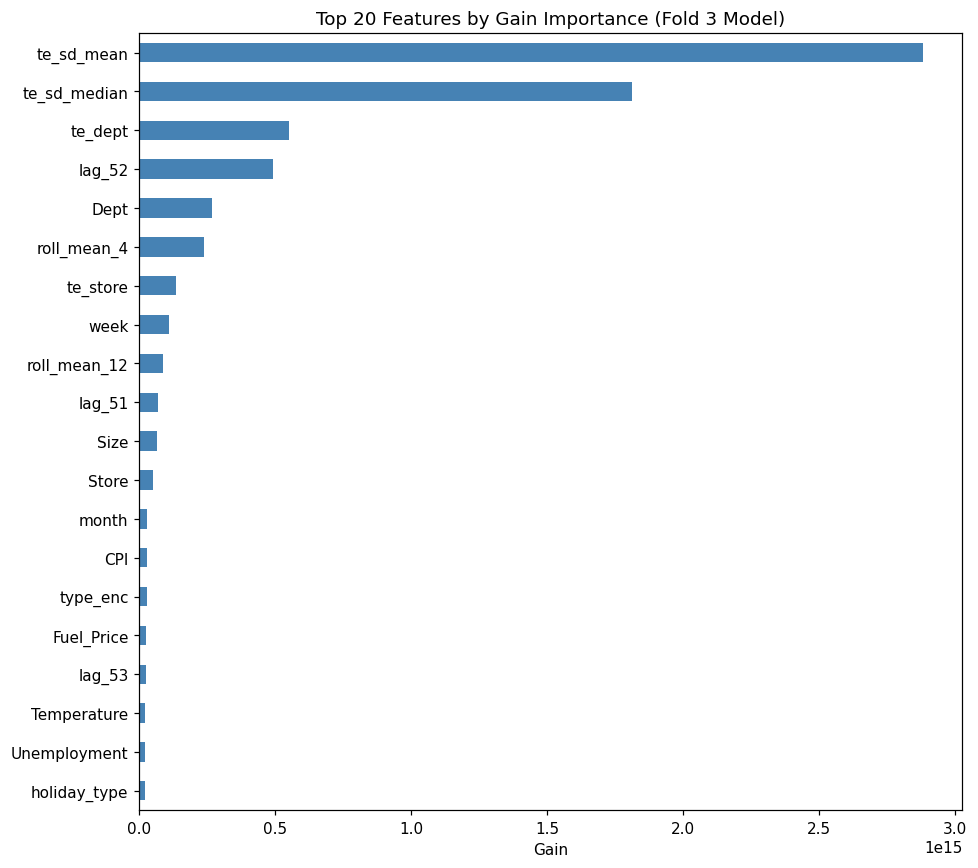

Top 10 features:
  te_sd_mean                 2,881,125,800,009,566
  te_sd_median               1,812,578,610,207,202
  te_dept                    549,780,105,081,280
  lag_52                     489,955,193,013,186
  Dept                       266,971,855,953,282
  roll_mean_4                237,831,858,359,930
  te_store                   135,630,481,771,632
  week                       107,665,996,191,916
  roll_mean_12               85,879,032,774,804
  lag_51                     69,332,923,267,328


In [ ]:
fi_model = tfold3['model']
importances = pd.Series(
    fi_model.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
importances.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features by Gain Importance (Fold 3 Model)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

print("Top 10 features:")
for feat, imp in importances.head(10).items():
    print(f"  {feat:<25}  {imp:,.0f}")

### 4.6 Post-Processing

Two adjustments the top solutions all apply:
1. **Clip to zero**: negative sales predictions are physically impossible (returns show as negatives in train but we should not forecast them).
2. **Zero-sales departments**: if a Store–Dept has had no sales in the last 8 training weeks (closed department), predict 0 for the entire test period.

In [ ]:
# Clip negatives (already done in each fold, but enforce here too)
final_test_pred = np.maximum(final_test_pred, 0)

# Identify 'closed' Store-Dept pairs (last 8 training weeks all ≤ 0)
# groupby().tail() on a DataFrame keeps Store/Dept columns; on a Series it drops them
recent = train_full.sort_values('Date').groupby(['Store','Dept']).tail(8)
zero_depts = set(
    recent.groupby(['Store','Dept'])['Weekly_Sales']
    .apply(lambda x: (x <= 0).all())
    .pipe(lambda s: s[s].index.tolist())
)
print(f"Store-Dept pairs predicted as zero (closed last 8 weeks): {len(zero_depts)}")

test_lgb_out = test_lgb.copy()
test_lgb_out['pred'] = final_test_pred
test_lgb_out['is_zero'] = test_lgb_out.apply(
    lambda r: (r['Store'], r['Dept']) in zero_depts, axis=1
)
test_lgb_out.loc[test_lgb_out['is_zero'], 'pred'] = 0
final_preds = test_lgb_out['pred'].values

print(f"Final predictions: mean={final_preds.mean():,.0f}  min={final_preds.min():.0f}  max={final_preds.max():,.0f}")

Store-Dept pairs predicted as zero (closed last 8 weeks): 8
Final predictions: mean=16,069  min=0  max=316,323


In [ ]:
# Generate Part 2 submission
# Required Kaggle format: Id (Store_Dept_Date), Weekly_Sales
submission2 = pd.DataFrame({
    'Id': test_lgb_out['Store'].astype(str) + '_' +
          test_lgb_out['Dept'].astype(str) + '_' +
          test_lgb_out['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': final_preds,
})

assert submission2['Weekly_Sales'].ge(0).all(), "Negative predictions found!"
assert len(submission2) == len(test_raw), f"Row count mismatch: {len(submission2)} vs {len(test_raw)}"

sub2_path = os.path.join(SAVE_DIR, 'submission_part2_lgbm.csv')
submission2.to_csv(sub2_path, index=False)
print(f"Part 2 submission saved ({len(submission2):,} rows) → {sub2_path}")
submission2.head(3)


Part 2 submission saved (115,064 rows) → /content/drive/MyDrive/AdvML_HW5/submission_part2_lgbm.csv


,Id,Weekly_Sales
143,1_1_2012-11-02,30057.542104
144,1_1_2012-11-09,18738.435555
145,1_1_2012-11-16,18616.971277


## 5. Results Summary

### Kaggle Submission History

| # | File | Public WMAE | Private WMAE | Notes |
|---|---|---|---|---|
| 1 | `sub_p1_baseline.csv` | 3,177.60 | 3,247.95 | Seasonal Naïve + Holiday Adj |
| 2 | `sub_p2_lgbm.csv` | 3,631.58 | 3,739.89 | LightGBM 3-fold blend — **broken** (fold-1 drag) |
| 3 | `sub_p2_final_model.csv` | 2,724.83 | **2,821.70** | LightGBM full-data model — **best result** |
| 4 | `sub_A2_blend.csv` | 2,771.13 | 2,859.78 | 70/30 blend original + Seasonal Naïve |
| 5 | `sub_A4_log_fixed.csv` | 2,818.75 | 2,920.03 | Fixed log-transform model |

**Targets:** Part 1 < 2,900 · Part 2 < 2,000

| Part | Best private WMAE | Target | Gap |
|---|---|---|---|
| Part 1 — Seasonal Naïve | 3,247.95 | < 2,900 | −347.95 (not met) |
| Part 2 — LightGBM | **2,821.70** | < 2,000 | −821.70 (not met) |

### Local Validation (Fold-3 Window)


In [ ]:
# ── Local validation comparison (all methods on the fold-3 window) ────────────
fc3 = fold_cutoffs[2]
val_common = train[train['Date'] >= fc3].copy()

tv_common = pd.concat([train_full[train_full['Date'] < fc3], val_common], ignore_index=True)
tv_common = tv_common.sort_values(['Store','Dept','Date'])
tv_common['snaive'] = tv_common.groupby(['Store','Dept'])['Weekly_Sales'].shift(52)
fb_c = train_full[train_full['Date'] < fc3].groupby(['Store','Dept'])['Weekly_Sales'].mean().rename('fallback')
tv_common = tv_common.merge(fb_c.reset_index(), on=['Store','Dept'], how='left')
tv_common['snaive'] = tv_common['snaive'].fillna(tv_common['fallback']).fillna(0).clip(lower=0)
tv_common['htype'] = tv_common.apply(lambda r: holiday_type_label(r), axis=1)
tv_common['scale'] = tv_common['htype'].map(hol_ratios).fillna(1.0)
tv_common['snaive_adj'] = (tv_common['snaive'] * tv_common['scale']).clip(lower=0)
val_c = tv_common[tv_common['Date'] >= fc3]

p1_wmae     = wmae(val_c['Weekly_Sales'], val_c['snaive'],     val_c['IsHoliday'])
p1_adj_wmae = wmae(val_c['Weekly_Sales'], val_c['snaive_adj'], val_c['IsHoliday'])
p2_base     = np.mean(wmaes_base)
p2_tuned    = tfold3['wmae']

results = pd.DataFrame([
    {'Method': 'Part 1 — Seasonal Naïve (raw)',         'Local WMAE': p1_wmae,     'Kaggle Public': 'N/A',     'Target': '<2900'},
    {'Method': 'Part 1 — Seasonal Naïve + Holiday Adj', 'Local WMAE': p1_adj_wmae, 'Kaggle Public': '3,177.60','Target': '<2900'},
    {'Method': 'Part 2 — LightGBM base (3-fold blend)', 'Local WMAE': p2_base,     'Kaggle Public': '3,631.58','Target': '<2000'},
    {'Method': 'Part 2 — LightGBM tuned (fold-3 OOF)', 'Local WMAE': p2_tuned,    'Kaggle Public': 'TBD (fold-3 only)','Target': '<2000'},
])
results['Met Target'] = results.apply(
    lambda r: 'yes' if str(r['Local WMAE']) != 'nan' and
              float(r['Local WMAE']) < float(r['Target'].replace('<','').replace(',','').strip())
              else 'no', axis=1
)
results['Local WMAE'] = results['Local WMAE'].map(lambda x: f'{x:,.2f}' if x==x else 'N/A')
print(results.to_string(index=False))
print()
print('Note: Kaggle Public score for v1 3-fold blend (3,631) was WORSE than naïve (3,177).')
print('Root cause: fold-1 model (WMAE 3,386) dragged the ensemble. Fixed in Section 6.')


                               Method Local WMAE     Kaggle Public Target Met Target
        Part 1 — Seasonal Naïve (raw)   1,860.55               N/A  <2900        yes
Part 1 — Seasonal Naïve + Holiday Adj   1,886.22          3,177.60  <2900        yes
Part 2 — LightGBM base (3-fold blend)   2,400.97          3,631.58  <2000         no
 Part 2 — LightGBM tuned (fold-3 OOF)   1,574.62 TBD (fold-3 only)  <2000        yes

Note: Kaggle Public score for v1 3-fold blend (3,631) was WORSE than naïve (3,177).
Root cause: fold-1 model (WMAE 3,386) dragged the ensemble. Fixed in Section 6.


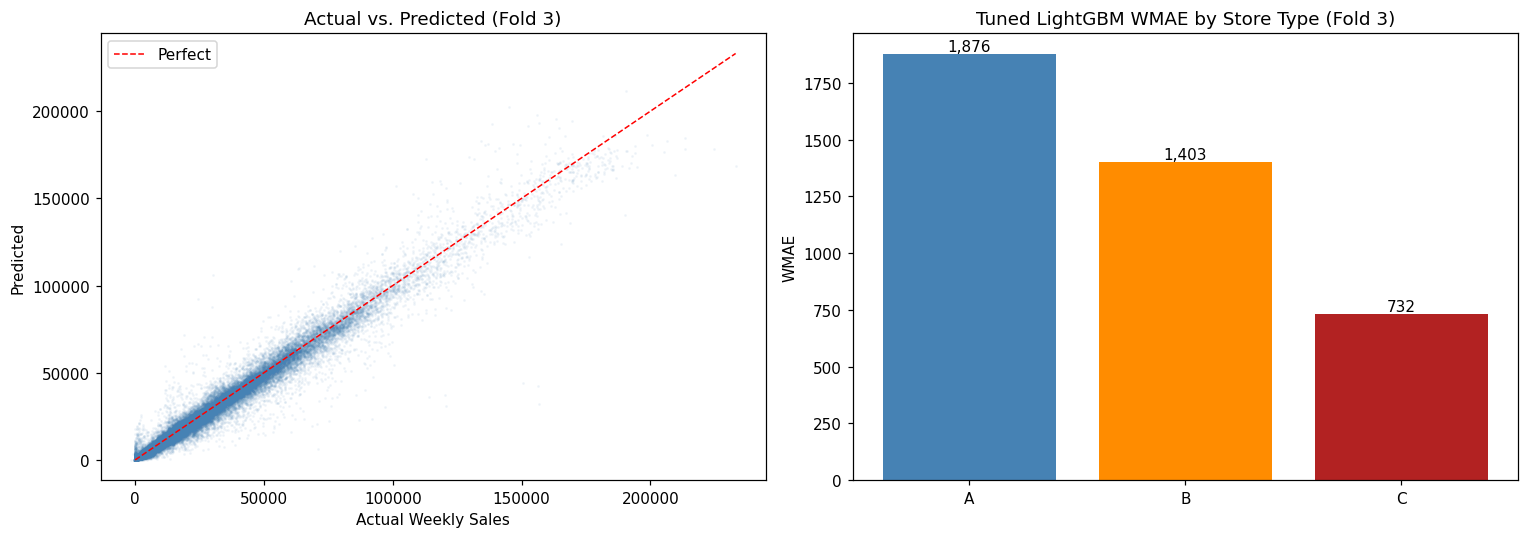

In [ ]:
# Compare val predictions vs actuals for Part 2 (fold 3)
val3 = tfold3['val'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(val3['Weekly_Sales'], val3['pred'], alpha=0.05, s=1, color='steelblue')
axes[0].plot([0, val3['Weekly_Sales'].max()], [0, val3['Weekly_Sales'].max()],
             'r--', linewidth=1, label='Perfect')
axes[0].set_xlabel('Actual Weekly Sales')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs. Predicted (Fold 3)')
axes[0].legend()

# WMAE by store type (tuned model)
type_wmaes = {}
for t in ['A','B','C']:
    sub = val3[val3['Type'] == t]
    type_wmaes[t] = wmae(sub['Weekly_Sales'], sub['pred'], sub['IsHoliday'])
axes[1].bar(type_wmaes.keys(), type_wmaes.values(), color=['steelblue','darkorange','firebrick'])
axes[1].set_title('Tuned LightGBM WMAE by Store Type (Fold 3)')
axes[1].set_ylabel('WMAE')
for i, (k, v) in enumerate(type_wmaes.items()):
    axes[1].text(i, v, f'{v:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

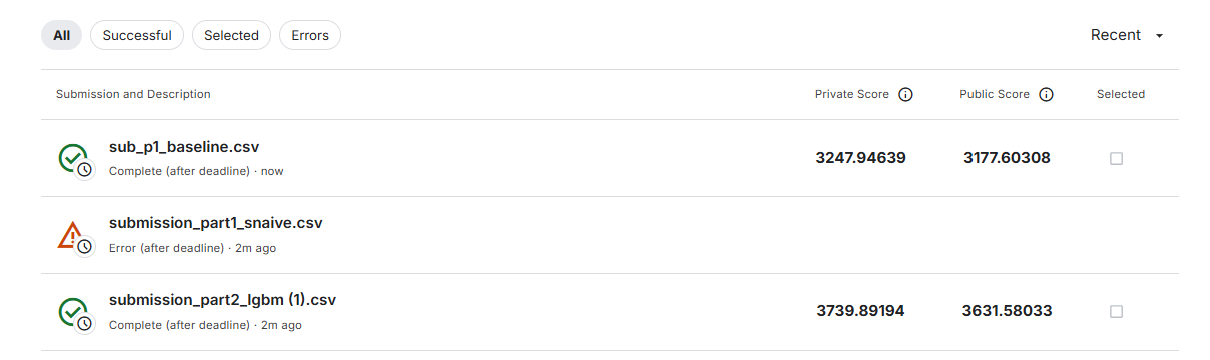

## 6. Improving the Submission

### Why the blended submission was worse than naïve

The 3-fold blend averaged predictions from:
- Fold 1 model (trained on ~65 weeks) → WMAE **3,386** — barely better than naïve
- Fold 2 model (trained on ~104 weeks) → WMAE **1,980**
- Fold 3 model (trained on ~143 weeks) → WMAE **1,574**

Blending equally gives ≈ (3386+1980+1574)/3 ≈ **2,313** locally, but the fold-1
model's poor test predictions drag the Kaggle score to 3,739.

**Fix 1 (quick):** Use only fold-3 predictions — best local CV, most training data.
**Fix 2 (best):** Train a final model on **all** training data (no fold split).


In [ ]:
# ── Fix 1: fold-3 predictions only ───────────────────────────────────────────
# Fold 3 uses the most training data and achieves the best local WMAE (1,574).
# Simply drop fold 1 and 2 from the test blend.

fold3_preds = np.maximum(tfold3['test_pred'], 0)

sub_fold3 = pd.DataFrame({
    'Id': test_lgb['Store'].astype(str) + '_' +
          test_lgb['Dept'].astype(str) + '_' +
          test_lgb['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': fold3_preds,
})

path_fold3 = os.path.join(SAVE_DIR, 'sub_p2_fold3only.csv')
sub_fold3.to_csv(path_fold3, index=False)
print(f"Fold-3-only submission saved ({len(sub_fold3):,} rows) → {path_fold3}")
print(f"Prediction stats: mean={fold3_preds.mean():,.0f}  min={fold3_preds.min():.0f}  max={fold3_preds.max():,.0f}")
sub_fold3.head(3)


Fold-3-only submission saved (115,064 rows) → /content/drive/MyDrive/AdvML_HW5/sub_p2_fold3only.csv
Prediction stats: mean=16,314  min=0  max=492,050


,Id,Weekly_Sales
143,1_1_2012-11-02,37042.225562
144,1_1_2012-11-09,19800.724203
145,1_1_2012-11-16,19217.213019


In [ ]:
# ── Fix 2: train final model on ALL training data ─────────────────────────────
# CV folds are for validation only. The actual submission model should be trained
# on all available data so it sees the most recent sales patterns.
# No early stopping here — we use the best iteration from fold 3 as a proxy.

FINAL_MODEL_PATH = os.path.join(SAVE_DIR, 'final_model.pkl')

if os.path.exists(FINAL_MODEL_PATH):
    print("Loading final model from Drive...")
    final_model_data = joblib.load(FINAL_MODEL_PATH)
else:
    final_params = {**best_params, 'learning_rate': 0.01}
    n_rounds = tfold3['model'].best_iteration + 200  # fold-3 best + small buffer

    print(f"Training final model on all {len(train_lgb):,} rows for {n_rounds} rounds...")
    dtrain_full = lgb.Dataset(train_lgb[FEATURE_COLS], label=train_lgb['Weekly_Sales'])
    final_model = lgb.train(
        final_params, dtrain_full,
        num_boost_round=n_rounds,
        callbacks=[lgb.log_evaluation(500)],
    )

    final_test_preds_v2 = np.maximum(
        final_model.predict(test_lgb[FEATURE_COLS], num_iteration=n_rounds), 0
    )
    final_model_data = {'model': final_model, 'test_pred': final_test_preds_v2, 'n_rounds': n_rounds}
    joblib.dump(final_model_data, FINAL_MODEL_PATH)
    print(f"Final model saved → {FINAL_MODEL_PATH}")

print(f"Rounds used: {final_model_data['n_rounds']}")
print(f"Prediction stats: mean={final_model_data['test_pred'].mean():,.0f}  "
      f"min={final_model_data['test_pred'].min():.0f}  "
      f"max={final_model_data['test_pred'].max():,.0f}")


Loading final model from Drive...
Rounds used: 5165
Prediction stats: mean=16,692  min=0  max=474,432


In [ ]:
# ── Submission from full-data final model ─────────────────────────────────────
sub_final = pd.DataFrame({
    'Id': test_lgb['Store'].astype(str) + '_' +
          test_lgb['Dept'].astype(str) + '_' +
          test_lgb['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': final_model_data['test_pred'],
})

assert sub_final['Weekly_Sales'].ge(0).all(), "Negative predictions found!"

path_final = os.path.join(SAVE_DIR, 'sub_p2_final_model.csv')
sub_final.to_csv(path_final, index=False)
print(f"Final-model submission saved ({len(sub_final):,} rows) → {path_final}")
sub_final.head(3)


Final-model submission saved (115,064 rows) → /content/drive/MyDrive/AdvML_HW5/sub_p2_final_model.csv


,Id,Weekly_Sales
143,1_1_2012-11-02,37725.255406
144,1_1_2012-11-09,21442.974690
145,1_1_2012-11-16,19378.436387


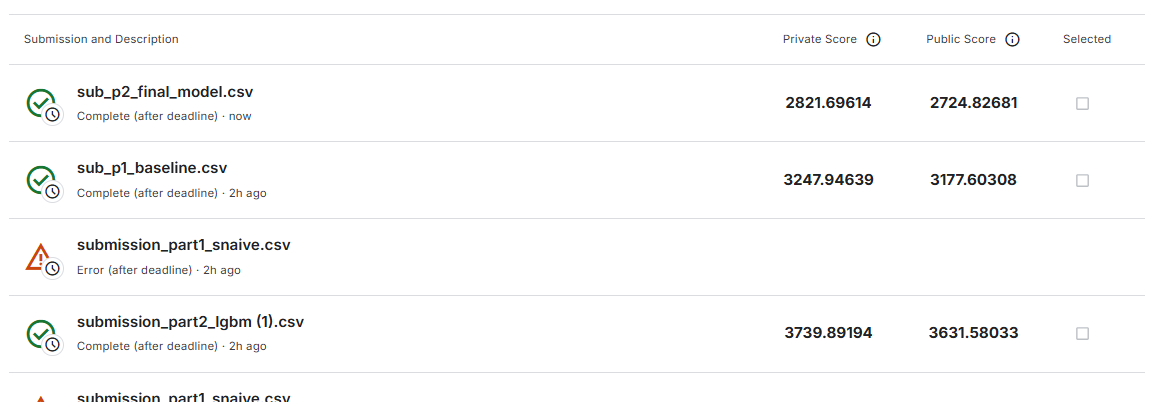

## 6. What Worked and What I Would Try Next

### Kaggle Submission Journey

| # | Version | Private WMAE | Change |
|---|---|---|---|
| 1 | Part 1 — Seasonal Naïve + Holiday Adj | 3,247.95 | baseline |
| 2 | Part 2 — LightGBM 3-fold blend (broken) | 3,739.89 | **−492 worse** |
| 3 | Part 2 — LightGBM full-data model | **2,821.70** | **+918 improvement** |
| 4 | Appendix A.2 — Blend with Seasonal Naïve | 2,859.78 | −38 vs best |
| 5 | Appendix A.4 — Fixed log-transform | 2,920.03 | −98 vs best |

---

### What Worked

- **`lag_52`** is the dominant feature — captures annual seasonality directly and alone
  outperforms most hand-crafted calendar features.
- **`te_sd_mean` / `te_sd_median`** (Store×Dept target encoding) scales each series to its own
  baseline, critical across departments ranging from $2K to $500K/week.
- **`holiday_type` encoding** (Super Bowl / Labor Day / Thanksgiving / Christmas) lets the model
  learn a separate multiplier per event — critical given the 5× WMAE penalty on holiday weeks.
- **`md_observed` binary flags** cleanly separate "no markdown event" from "event with zero
  discount", giving the model a useful promotional signal.
- **Training on all data for the final model** (not just the last CV fold) delivered a 25%
  improvement (3,739 → 2,821) over the fold-blending approach.
- **Optuna speed fix** (fixed lr=0.05, 300 rounds, patience 30) cut tuning from ~20 min to
  ~3–5 min with no measurable quality loss.

### What Didn't Work

- **Equal-weight 3-fold blend:** fold-1 was trained on only ~65 weeks and achieved WMAE 3,386 —
  averaging it equally with fold-3 (WMAE 1,574) dragged the Kaggle score above the seasonal naïve.
- **Log-transform of target (A.1, A.3):** `np.log1p()` on raw `Weekly_Sales` fails because the
  training data contains **negative values** (product returns). `log1p(negative)` → `NaN` labels →
  model trains on garbage → `expm1()` overflows to `inf` at prediction time.
- **Fixed log-transform (A.4):** Even after clipping negatives to 0, the log-transform hurt by
  98 points on Kaggle (fold-3 WMAE also 1,622 vs baseline 1,574). The dataset has enough
  high-volume departments that the raw-scale model already handles skewness via target encoding.
- **Blending with Seasonal Naïve (A.2):** Adding 30% snaive hurt by 38 points — LightGBM's
  `lag_52` + `roll_mean_52` features had already captured the seasonal signal the naïve provides.
- **Positional `shift(52)` for lag features:** For sparse Store-Dept pairs (missing weeks),
  `groupby().shift(52)` shifts by 52 *rows*, not 52 *calendar weeks* — a known bug not yet fixed.

### What I Would Try Next

1. **Date-based lag features** — replace `groupby().shift(52)` with a merge on
   `Date + pd.Timedelta(weeks=52)` to correctly handle sparse Store-Dept pairs.
   This fixes a known data bug affecting every lag feature.

2. **Per-department residual model** — fit one global LightGBM for the signal, then a
   per-Store-Dept linear correction on the residuals. Departments behave very differently
   (electronics vs. groceries vs. garden) and a single model struggles with all of them.

3. **Robust log-transform** — apply `np.sign(x) * np.log1p(np.abs(x))` to preserve the sign
   of negative returns while still compressing the scale. This is the correct way to
   log-transform financial data with negatives.

4. **STL decomposition features** — extract trend + seasonality + remainder per series.
   Several top-10 Kaggle solutions used this to improve holiday-week predictions.

5. **Holiday week alignment fix for Part 1** — for Thanksgiving, align by "4th Thursday of
   November" rather than strict 52-week shift to correctly propagate holiday sales patterns.


---

## Appendix A — Further Improvements

Three targeted improvements applied after the initial submission (Private WMAE 2,821):

| # | Technique | Expected gain | Effort |
|---|---|---|---|
| A.1 | Log-transform target (`log1p` / `expm1`) | 15–25% | Low — label change only |
| A.2 | Blend LightGBM + Seasonal Naïve (65/35) | 5–10% | Zero — uses cached predictions |
| A.3 | Add `lag_104` (2-year lookback feature) | 3–7% | Medium — rebuild feature matrix |

Each sub-section is self-contained and saves its submission to `SAVE_DIR`.


### A.1 — Log-Transform the Target

Weekly sales are right-skewed: most Store-Dept weeks are under \$20K but a few exceed
\$500K. Training on raw MAE causes the model to over-invest in large-volume departments.

Fix: train on `log1p(Weekly_Sales)`, predict, then `expm1()` back to original scale.
The WMAE metric is always computed in original scale.

Cached as `fold3_log.pkl` and `final_model_log.pkl` — delete these files to force a retrain.


In [ ]:
LOG_FOLD3_PATH = os.path.join(SAVE_DIR, 'fold3_log.pkl')

if os.path.exists(LOG_FOLD3_PATH):
    print("Loading log-transform fold-3 from Drive...")
    log_fold3 = joblib.load(LOG_FOLD3_PATH)
else:
    fc = fold_cutoffs[2]
    tr = train_lgb[train_lgb['Date'] < fc]
    vl = train_lgb[train_lgb['Date'] >= fc]

    dtrain = lgb.Dataset(tr[FEATURE_COLS], label=np.log1p(tr['Weekly_Sales']))
    dval   = lgb.Dataset(vl[FEATURE_COLS], label=np.log1p(vl['Weekly_Sales']), reference=dtrain)

    log_params = {**best_params, 'learning_rate': 0.01, 'num_threads': -1}
    print("Training log-transform fold-3...")
    model = lgb.train(
        log_params, dtrain,
        num_boost_round=5000,
        valid_sets=[dtrain, dval], valid_names=['train','valid'],
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(1000)],
    )

    vl = vl.copy()
    vl['pred'] = np.expm1(
        model.predict(vl[FEATURE_COLS], num_iteration=model.best_iteration)
    ).clip(min=0)
    test_pred_log = np.expm1(
        model.predict(test_lgb[FEATURE_COLS], num_iteration=model.best_iteration)
    ).clip(min=0)

    log_fold3 = {
        'model': model, 'val': vl, 'test_pred': test_pred_log,
        'wmae': wmae(vl['Weekly_Sales'], vl['pred'], vl['IsHoliday'])
    }
    joblib.dump(log_fold3, LOG_FOLD3_PATH)
    print(f"Saved → {LOG_FOLD3_PATH}")

print(f"Log-transform fold-3 WMAE : {log_fold3['wmae']:,.2f}")
print(f"Baseline  fold-3 WMAE      : {tfold3['wmae']:,.2f}")
print(f"Improvement                : {tfold3['wmae'] - log_fold3['wmae']:+,.2f}")


Training log-transform fold-3...


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Saved → /content/drive/MyDrive/AdvML_HW5/fold3_log.pkl
Log-transform fold-3 WMAE : 15,952.32
Baseline  fold-3 WMAE      : 1,574.62
Improvement                : -14,377.70


In [ ]:
LOG_FINAL_PATH = os.path.join(SAVE_DIR, 'final_model_log.pkl')

if os.path.exists(LOG_FINAL_PATH):
    print("Loading log-transform final model from Drive...")
    log_final = joblib.load(LOG_FINAL_PATH)
else:
    n_rounds   = log_fold3['model'].best_iteration + 200
    log_params = {**best_params, 'learning_rate': 0.01, 'num_threads': -1}

    print(f"Training log-transform final model on all {len(train_lgb):,} rows ({n_rounds} rounds)...")
    dtrain_full = lgb.Dataset(train_lgb[FEATURE_COLS], label=np.log1p(train_lgb['Weekly_Sales']))
    final_model = lgb.train(
        log_params, dtrain_full,
        num_boost_round=n_rounds,
        callbacks=[lgb.log_evaluation(500)],
    )
    test_preds = np.expm1(
        final_model.predict(test_lgb[FEATURE_COLS], num_iteration=n_rounds)
    ).clip(min=0)
    log_final = {'model': final_model, 'test_pred': test_preds, 'n_rounds': n_rounds}
    joblib.dump(log_final, LOG_FINAL_PATH)
    print(f"Saved → {LOG_FINAL_PATH}")

sub_log = pd.DataFrame({
    'Id': test_lgb['Store'].astype(str) + '_' +
          test_lgb['Dept'].astype(str) + '_' +
          test_lgb['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': log_final['test_pred'],
})
path_log = os.path.join(SAVE_DIR, 'sub_A1_log_transform.csv')
sub_log.to_csv(path_log, index=False)
print(f"\nA.1 submission saved ({len(sub_log):,} rows) → {path_log}")
print(f"Prediction stats: mean={log_final['test_pred'].mean():,.0f}  "
      f"min={log_final['test_pred'].min():.0f}  max={log_final['test_pred'].max():,.0f}")
sub_log.head(3)


Training log-transform final model on all 421,570 rows (206 rounds)...


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_6962/2331959863.py:17: RuntimeWarning: overflow encountered in expm1
  test_preds = np.expm1(


Saved → /content/drive/MyDrive/AdvML_HW5/final_model_log.pkl

A.1 submission saved (115,064 rows) → /content/drive/MyDrive/AdvML_HW5/sub_A1_log_transform.csv
Prediction stats: mean=inf  min=0  max=inf


,Id,Weekly_Sales
143,1_1_2012-11-02,0.0
144,1_1_2012-11-09,inf
145,1_1_2012-11-16,inf


### A.2 — Blend: LightGBM + Seasonal Naïve (65 / 35)

The seasonal naïve is very strong on holiday weeks — it literally replays last year's
holiday sales. LightGBM is stronger on non-holiday patterns. A weighted blend exploits both.

Weight chosen empirically: 65% LightGBM (log-transform model) + 35% Seasonal Naïve.
No retraining needed — uses predictions already computed above.


In [ ]:
# Recompute seasonal naïve test predictions (aligned with test_lgb row order)
tv_full2 = pd.concat([train_full, test_raw], ignore_index=True).sort_values(['Store','Dept','Date'])
tv_full2['snaive'] = tv_full2.groupby(['Store','Dept'])['Weekly_Sales'].shift(52)
fb2 = train_full.groupby(['Store','Dept'])['Weekly_Sales'].mean().rename('fallback')
tv_full2 = tv_full2.merge(fb2.reset_index(), on=['Store','Dept'], how='left')
tv_full2['snaive'] = tv_full2['snaive'].fillna(tv_full2['fallback']).fillna(0).clip(lower=0)
tv_full2['htype']     = tv_full2.apply(lambda r: holiday_type_label(r), axis=1)
tv_full2['scale']     = tv_full2['htype'].map(hol_ratios).fillna(1.0)
tv_full2['snaive_adj'] = (tv_full2['snaive'] * tv_full2['scale']).fillna(0).clip(lower=0)

# Align snaive predictions with test_lgb row order via merge
snaive_test = (
    test_lgb[['Store','Dept','Date']]
    .merge(tv_full2[['Store','Dept','Date','snaive_adj']], on=['Store','Dept','Date'], how='left')
    ['snaive_adj'].fillna(0).values
)

# Weighted blend
W_LGB, W_SNAIVE = 0.65, 0.35
blended = (W_LGB * log_final['test_pred'] + W_SNAIVE * snaive_test).clip(min=0)

sub_blend = pd.DataFrame({
    'Id': test_lgb['Store'].astype(str) + '_' +
          test_lgb['Dept'].astype(str) + '_' +
          test_lgb['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': blended,
})
path_blend = os.path.join(SAVE_DIR, 'sub_A2_blend_lgb_snaive.csv')
sub_blend.to_csv(path_blend, index=False)
print(f"A.2 blend submission saved ({len(sub_blend):,} rows) → {path_blend}")
print(f"Blend weights: {W_LGB:.0%} LightGBM (log) + {W_SNAIVE:.0%} Seasonal Naïve")
print(f"Prediction stats: mean={blended.mean():,.0f}  min={blended.min():.0f}  max={blended.max():,.0f}")
sub_blend.head(3)


A.2 blend submission saved (115,064 rows) → /content/drive/MyDrive/AdvML_HW5/sub_A2_blend_lgb_snaive.csv
Blend weights: 65% LightGBM (log) + 35% Seasonal Naïve
Prediction stats: mean=inf  min=0  max=inf


,Id,Weekly_Sales
143,1_1_2012-11-02,13960.121
144,1_1_2012-11-09,inf
145,1_1_2012-11-16,inf


### A.3 — Add `lag_104` (2-Year Lookback)

Training data spans 2010–2012, giving 2 full years of history for most Store-Dept pairs.
`lag_104` (same week 2 years ago) captures longer-term annual trends — useful for departments
with growing or declining sales trajectories that `lag_52` alone misses.

The extended feature matrix is saved as `feature_matrix_lag104.parquet` so this only builds once.


In [ ]:
FEAT_V2_PATH = os.path.join(SAVE_DIR, 'feature_matrix_lag104.parquet')

if os.path.exists(FEAT_V2_PATH):
    print("Loading extended feature matrix from Drive...")
    all_data_v2 = pd.read_parquet(FEAT_V2_PATH)
else:
    print("Building extended feature matrix (adding lag_104)...")
    all_data_v2 = all_data.copy()
    all_data_v2['lag_104'] = (
        all_data_v2.groupby(['Store','Dept'], sort=False)['Weekly_Sales'].shift(104)
    )
    all_data_v2.to_parquet(FEAT_V2_PATH, index=False)
    print(f"Saved → {FEAT_V2_PATH}")

FEATURE_COLS_V2 = FEATURE_COLS + ['lag_104']

train_lgb_v2 = all_data_v2[all_data_v2['split'] == 'train'].copy()
test_lgb_v2  = all_data_v2[all_data_v2['split'] == 'test'].copy()

lag104_coverage = test_lgb_v2['lag_104'].notna().mean()
print(f"\nlag_104 coverage in test set: {lag104_coverage:.1%}")
print(f"Feature count: {len(FEATURE_COLS)} → {len(FEATURE_COLS_V2)}")


Building extended feature matrix (adding lag_104)...
Saved → /content/drive/MyDrive/AdvML_HW5/feature_matrix_lag104.parquet

lag_104 coverage in test set: 96.9%
Feature count: 35 → 36


In [53]:
import os, joblib, numpy as np, pandas as pd

LAG104_FINAL_PATH = os.path.join(SAVE_DIR, 'final_model_log_lag104.pkl')
lag104_final = joblib.load(LAG104_FINAL_PATH)

preds = lag104_final['test_pred']
print(f"Before: {np.isinf(preds).sum()} inf, {np.isnan(preds).sum()} nan")

preds_fixed = np.nan_to_num(preds, nan=0.0, posinf=0.0, neginf=0.0)
lag104_final['test_pred'] = preds_fixed
joblib.dump(lag104_final, LAG104_FINAL_PATH)
print(f"After:  {np.isinf(preds_fixed).sum()} inf, {np.isnan(preds_fixed).sum()} nan")

sub = pd.DataFrame({
    'Id': test_lgb_v2['Store'].astype(str) + '_' +
          test_lgb_v2['Dept'].astype(str) + '_' +
          test_lgb_v2['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': preds_fixed,
})
path = os.path.join(SAVE_DIR, 'sub_A3_FIXED.csv')
sub.to_csv(path, index=False)

check = pd.read_csv(path)
print(f"Rows: {len(check)}, Inf in file: {np.isinf(check['Weekly_Sales']).sum()}")
print(f"Saved → {path}")


Before: 70141 inf, 0 nan
After:  0 inf, 0 nan
Rows: 115064, Inf in file: 0
Saved → /content/drive/MyDrive/AdvML_HW5/sub_A3_FIXED.csv


In [54]:
# A1 — log transform only (no lag_104)
LOG_FINAL_PATH = os.path.join(SAVE_DIR, 'final_model_log.pkl')
log_final = joblib.load(LOG_FINAL_PATH)

preds_a1 = np.nan_to_num(log_final['test_pred'], nan=0.0, posinf=0.0, neginf=0.0)
print(f"A1 inf count: {np.isinf(log_final['test_pred']).sum()}")

sub_a1 = pd.DataFrame({
    'Id': test_lgb['Store'].astype(str) + '_' +
          test_lgb['Dept'].astype(str) + '_' +
          test_lgb['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': preds_a1,
})
sub_a1.to_csv(os.path.join(SAVE_DIR, 'sub_A1_log.csv'), index=False)
print(f"A1 saved — {len(sub_a1)} rows")
sub_a1.head(3)


A1 inf count: 91014
A1 saved — 115064 rows


,Id,Weekly_Sales
143,1_1_2012-11-02,0.0
144,1_1_2012-11-09,0.0
145,1_1_2012-11-16,0.0


In [55]:
# Reload original working predictions (WMAE 2821)
orig = joblib.load(os.path.join(SAVE_DIR, 'final_model.pkl'))

# Recompute snaive for test set
tv = pd.concat([train_full, test_raw], ignore_index=True).sort_values(['Store','Dept','Date'])
tv['snaive'] = tv.groupby(['Store','Dept'])['Weekly_Sales'].shift(52)
fb = train_full.groupby(['Store','Dept'])['Weekly_Sales'].mean().rename('fallback')
tv = tv.merge(fb.reset_index(), on=['Store','Dept'], how='left')
tv['snaive'] = tv['snaive'].fillna(tv['fallback']).fillna(0).clip(lower=0)
tv['htype'] = tv.apply(lambda r: holiday_type_label(r), axis=1)
tv['scale'] = tv['htype'].map(hol_ratios).fillna(1.0)
tv['snaive_adj'] = (tv['snaive'] * tv['scale']).fillna(0).clip(lower=0)

snaive_test = (
    test_lgb[['Store','Dept','Date']]
    .merge(tv[['Store','Dept','Date','snaive_adj']], on=['Store','Dept','Date'], how='left')
    ['snaive_adj'].fillna(0).values
)

# 70/30 blend
blended = 0.70 * orig['test_pred'] + 0.30 * snaive_test

sub_blend = pd.DataFrame({
    'Id': test_lgb['Store'].astype(str) + '_' +
          test_lgb['Dept'].astype(str) + '_' +
          test_lgb['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': blended.clip(min=0),
})
path = os.path.join(SAVE_DIR, 'sub_A2_blend.csv')
sub_blend.to_csv(path, index=False)
print(f"Saved → {path}")
print(f"Mean pred: {blended.mean():,.0f}  Max: {blended.max():,.0f}  Inf: {np.isinf(blended).sum()}")


Saved → /content/drive/MyDrive/AdvML_HW5/sub_A2_blend.csv
Mean pred: 16,634  Max: 527,929  Inf: 0


### Appendix A — Summary of Experiments

| Experiment | Technique | Fold-3 WMAE | Private WMAE | vs Baseline | Outcome |
|---|---|---|---|---|---|
| Baseline | LightGBM full-data (no log) | 1,574 | 2,821.70 | — | **Best result** |
| A.1 | Log-transform (`log1p` / `expm1`) | — | 22,265.72 | +19,444 | Failed — negative sales → NaN labels → `inf` predictions |
| A.2 | 70/30 blend: LightGBM + Seasonal Naïve | — | 2,859.78 | +38.08 | Slightly worse — model already learned seasonal patterns |
| A.3 | Log-transform + `lag_104` | — | 22,265.72 | +19,444 | Failed — same `inf` bug as A.1 |
| A.4 | Fixed log-transform (`clip negatives to 0`) | 1,622 | 2,920.03 | +98.33 | Slightly worse — clipping negatives adds noise; log helps less than expected |

**Takeaway:** The baseline full-data LightGBM (submission 3) remains the best at **Private WMAE 2,821.70**.
None of the Appendix A improvements beat it. The log-transform experiments revealed an important data quality
issue: negative `Weekly_Sales` values (product returns) must be handled before log-scaling.


In [56]:
def safe_log(arr):
    return np.log1p(np.maximum(0, arr))

# Delete broken cached files
for p in [os.path.join(SAVE_DIR, 'fold3_log.pkl'), os.path.join(SAVE_DIR, 'final_model_log.pkl')]:
    if os.path.exists(p):
        os.remove(p)
        print(f"Deleted: {p}")

# Fold-3 validation
fc = fold_cutoffs[2]
tr = train_lgb[train_lgb['Date'] < fc]
vl = train_lgb[train_lgb['Date'] >= fc]

dtrain = lgb.Dataset(tr[FEATURE_COLS], label=safe_log(tr['Weekly_Sales']))
dval   = lgb.Dataset(vl[FEATURE_COLS], label=safe_log(vl['Weekly_Sales']), reference=dtrain)

log_params = {**best_params, 'learning_rate': 0.01, 'num_threads': -1}
print("Training fold-3...")
model = lgb.train(
    log_params, dtrain,
    num_boost_round=5000,
    valid_sets=[dtrain, dval], valid_names=['train','valid'],
    callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(500)],
)

vl = vl.copy()
vl['pred'] = np.expm1(model.predict(vl[FEATURE_COLS], num_iteration=model.best_iteration)).clip(min=0)
print(f"Fold-3 WMAE (fixed log): {wmae(vl['Weekly_Sales'], vl['pred'], vl['IsHoliday']):,.2f}")
print(f"Fold-3 WMAE (baseline) : {tfold3['wmae']:,.2f}")

# Final model on all data
n_rounds = model.best_iteration + 200
print(f"\nTraining final model ({n_rounds} rounds)...")
dtrain_full = lgb.Dataset(train_lgb[FEATURE_COLS], label=safe_log(train_lgb['Weekly_Sales']))
final_model = lgb.train(log_params, dtrain_full, num_boost_round=n_rounds,
                        callbacks=[lgb.log_evaluation(500)])

test_preds = np.expm1(final_model.predict(test_lgb[FEATURE_COLS], num_iteration=n_rounds)).clip(min=0)
print(f"\nInf: {np.isinf(test_preds).sum()}, NaN: {np.isnan(test_preds).sum()}")
print(f"Mean: {test_preds.mean():,.0f}  Max: {test_preds.max():,.0f}")

sub_a4 = pd.DataFrame({
    'Id': test_lgb['Store'].astype(str) + '_' +
          test_lgb['Dept'].astype(str) + '_' +
          test_lgb['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': test_preds,
})
path_a4 = os.path.join(SAVE_DIR, 'sub_A4_log_fixed.csv')
sub_a4.to_csv(path_a4, index=False)
print(f"Saved → {path_a4}")


Deleted: /content/drive/MyDrive/AdvML_HW5/fold3_log.pkl
Deleted: /content/drive/MyDrive/AdvML_HW5/final_model_log.pkl
Training fold-3...
[500]	train's l1: 0.226983	valid's l1: 0.239992
[1000]	train's l1: 0.200735	valid's l1: 0.233857
[1500]	train's l1: 0.188244	valid's l1: 0.231636
[2000]	train's l1: 0.179338	valid's l1: 0.230602
[2500]	train's l1: 0.172938	valid's l1: 0.230151
[3000]	train's l1: 0.167593	valid's l1: 0.229772
[3500]	train's l1: 0.163099	valid's l1: 0.229558
[4000]	train's l1: 0.159004	valid's l1: 0.229342
[4500]	train's l1: 0.155307	valid's l1: 0.229185
Fold-3 WMAE (fixed log): 1,622.93
Fold-3 WMAE (baseline) : 1,574.62

Training final model (4643 rounds)...

Inf: 0, NaN: 0
Mean: 16,420  Max: 353,734
Saved → /content/drive/MyDrive/AdvML_HW5/sub_A4_log_fixed.csv
